In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [ ]:
prices_raw_2 = pd.read_csv("prices_round_5_day_2.csv", sep = ";", index_col = "timestamp")
prices_raw_3 = pd.read_csv("prices_round_5_day_3.csv", sep = ";", index_col = "timestamp")
prices_raw_4 = pd.read_csv("prices_round_5_day_4.csv", sep = ";", index_col = "timestamp")

prices_raw_3.index = prices_raw_3.index + prices_raw_2.index.max() + 100
prices_raw_4.index = prices_raw_4.index + prices_raw_3.index.max() + 100
prices_raw = pd.concat([prices_raw_2, prices_raw_3, prices_raw_4], axis=0)

mid_prices = prices_raw[["product", "mid_price"]]
mid_prices = (
    mid_prices.reset_index()  # makes timestamp a normal column (usually named "timestamp")
       .pivot(index="timestamp", columns="product", values="mid_price")
       .sort_index()
)

gs = mid_prices.filter(regex=r'^GALAXY_SOUNDS')
mc = mid_prices.filter(regex=r'^MICROCHIP')
os = mid_prices.filter(regex=r'^OXYGEN_SHAKE')
panel = mid_prices.filter(regex=r'^PANEL')
pebble = mid_prices.filter(regex=r'^PEBBLES')
robot = mid_prices.filter(regex=r'^ROBOT')
sleep = mid_prices.filter(regex=r'^SLEEP_POD')
sp = mid_prices.filter(regex=r'^SNACKPACK')
trans = mid_prices.filter(regex=r'^TRANSLATOR')
uv = mid_prices.filter(regex=r'^UV_VISOR')

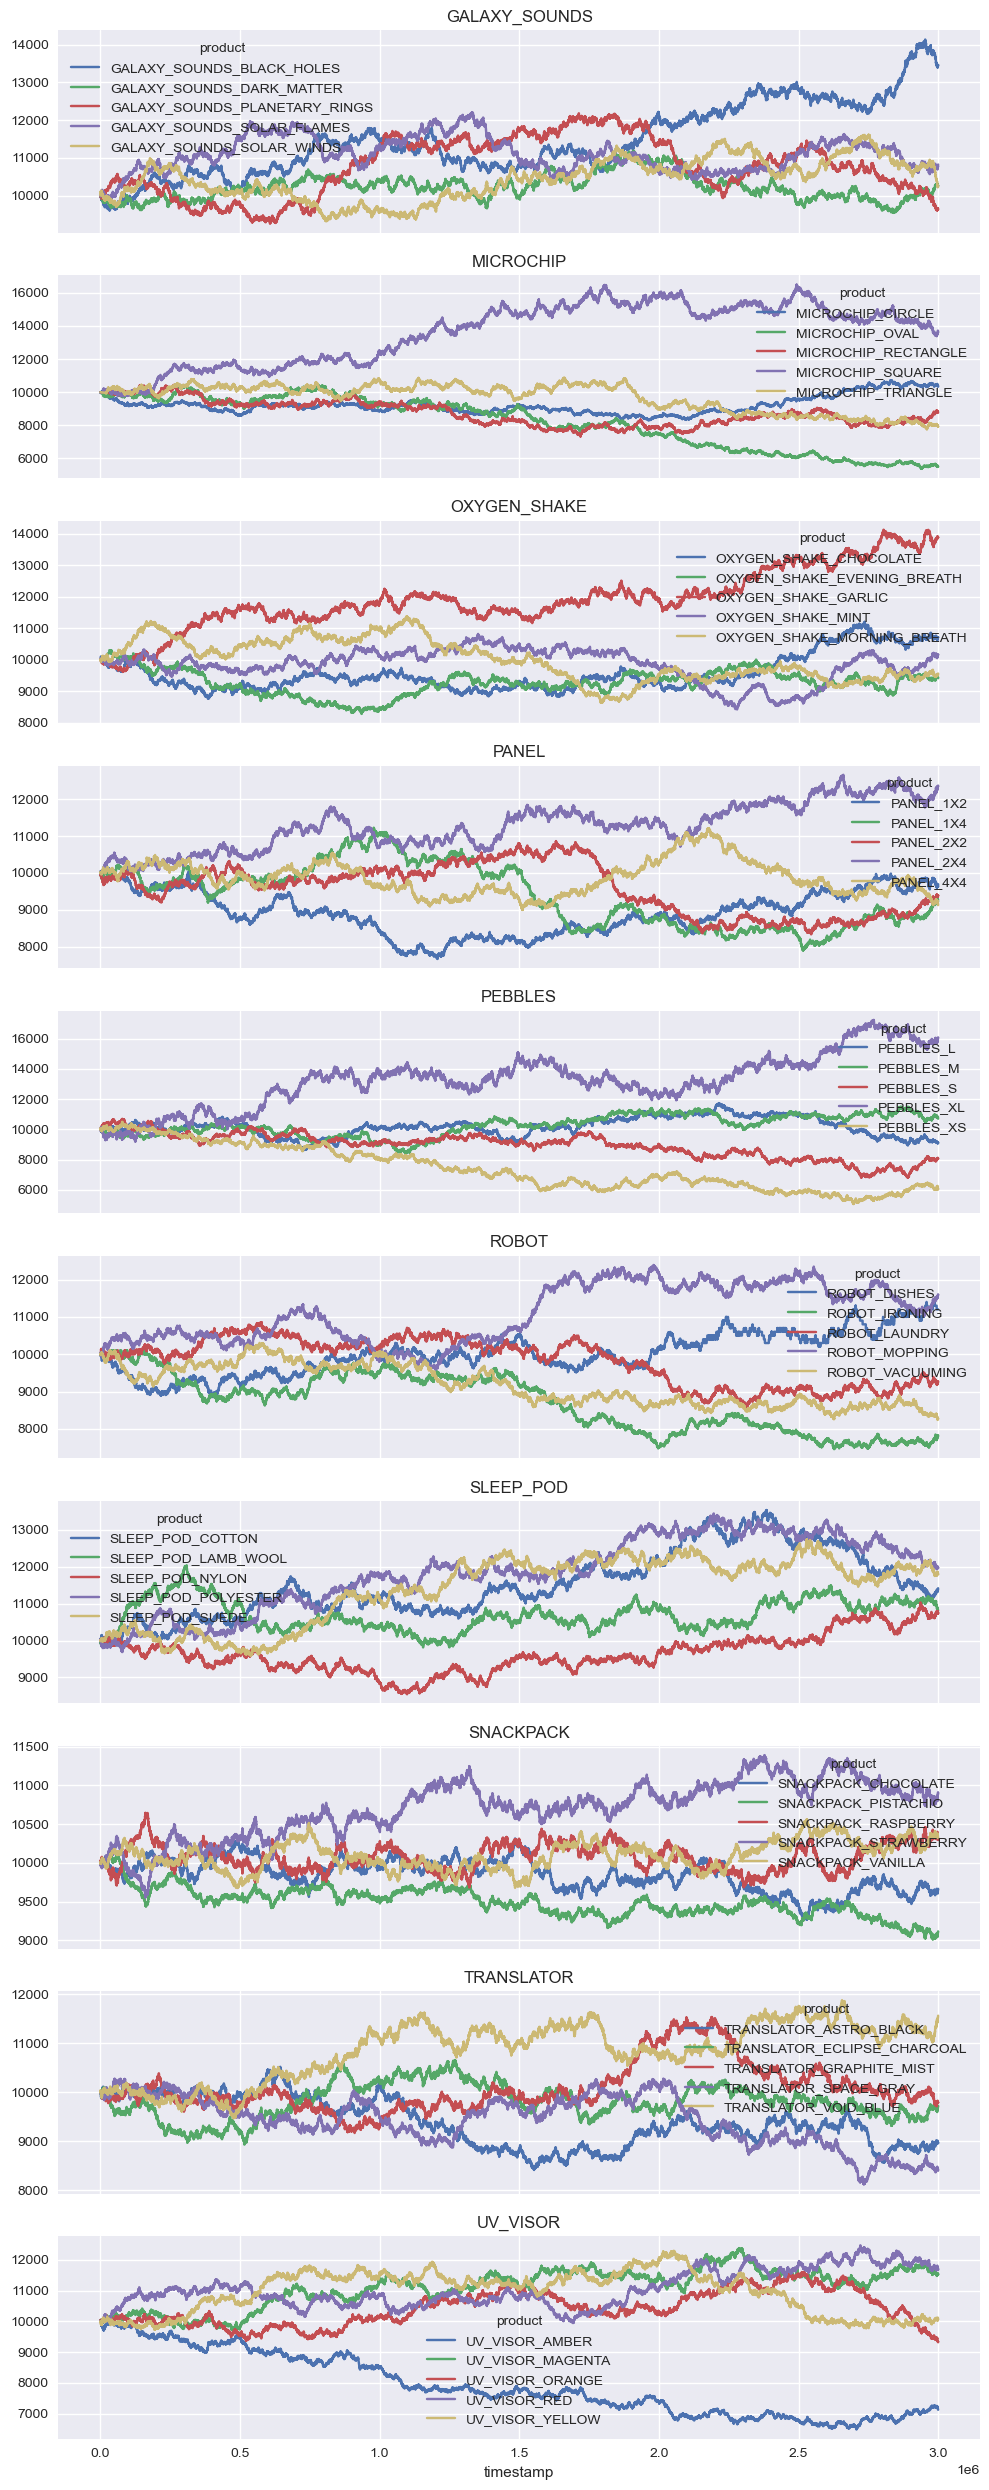

In [11]:
sectors = {
    "GALAXY_SOUNDS": gs,
    "MICROCHIP": mc,
    "OXYGEN_SHAKE": os,
    "PANEL": panel,
    "PEBBLES": pebble,
    "ROBOT": robot,
    "SLEEP_POD": sleep,
    "SNACKPACK": sp,
    "TRANSLATOR": trans,
    "UV_VISOR": uv
}

fig, axes = plt.subplots(len(sectors), 1, figsize=(10, 25), sharex=True)

for ax, (name, df) in zip(axes, sectors.items()):
    df.plot(ax=ax, title=name, legend=True)

plt.tight_layout()
plt.show()

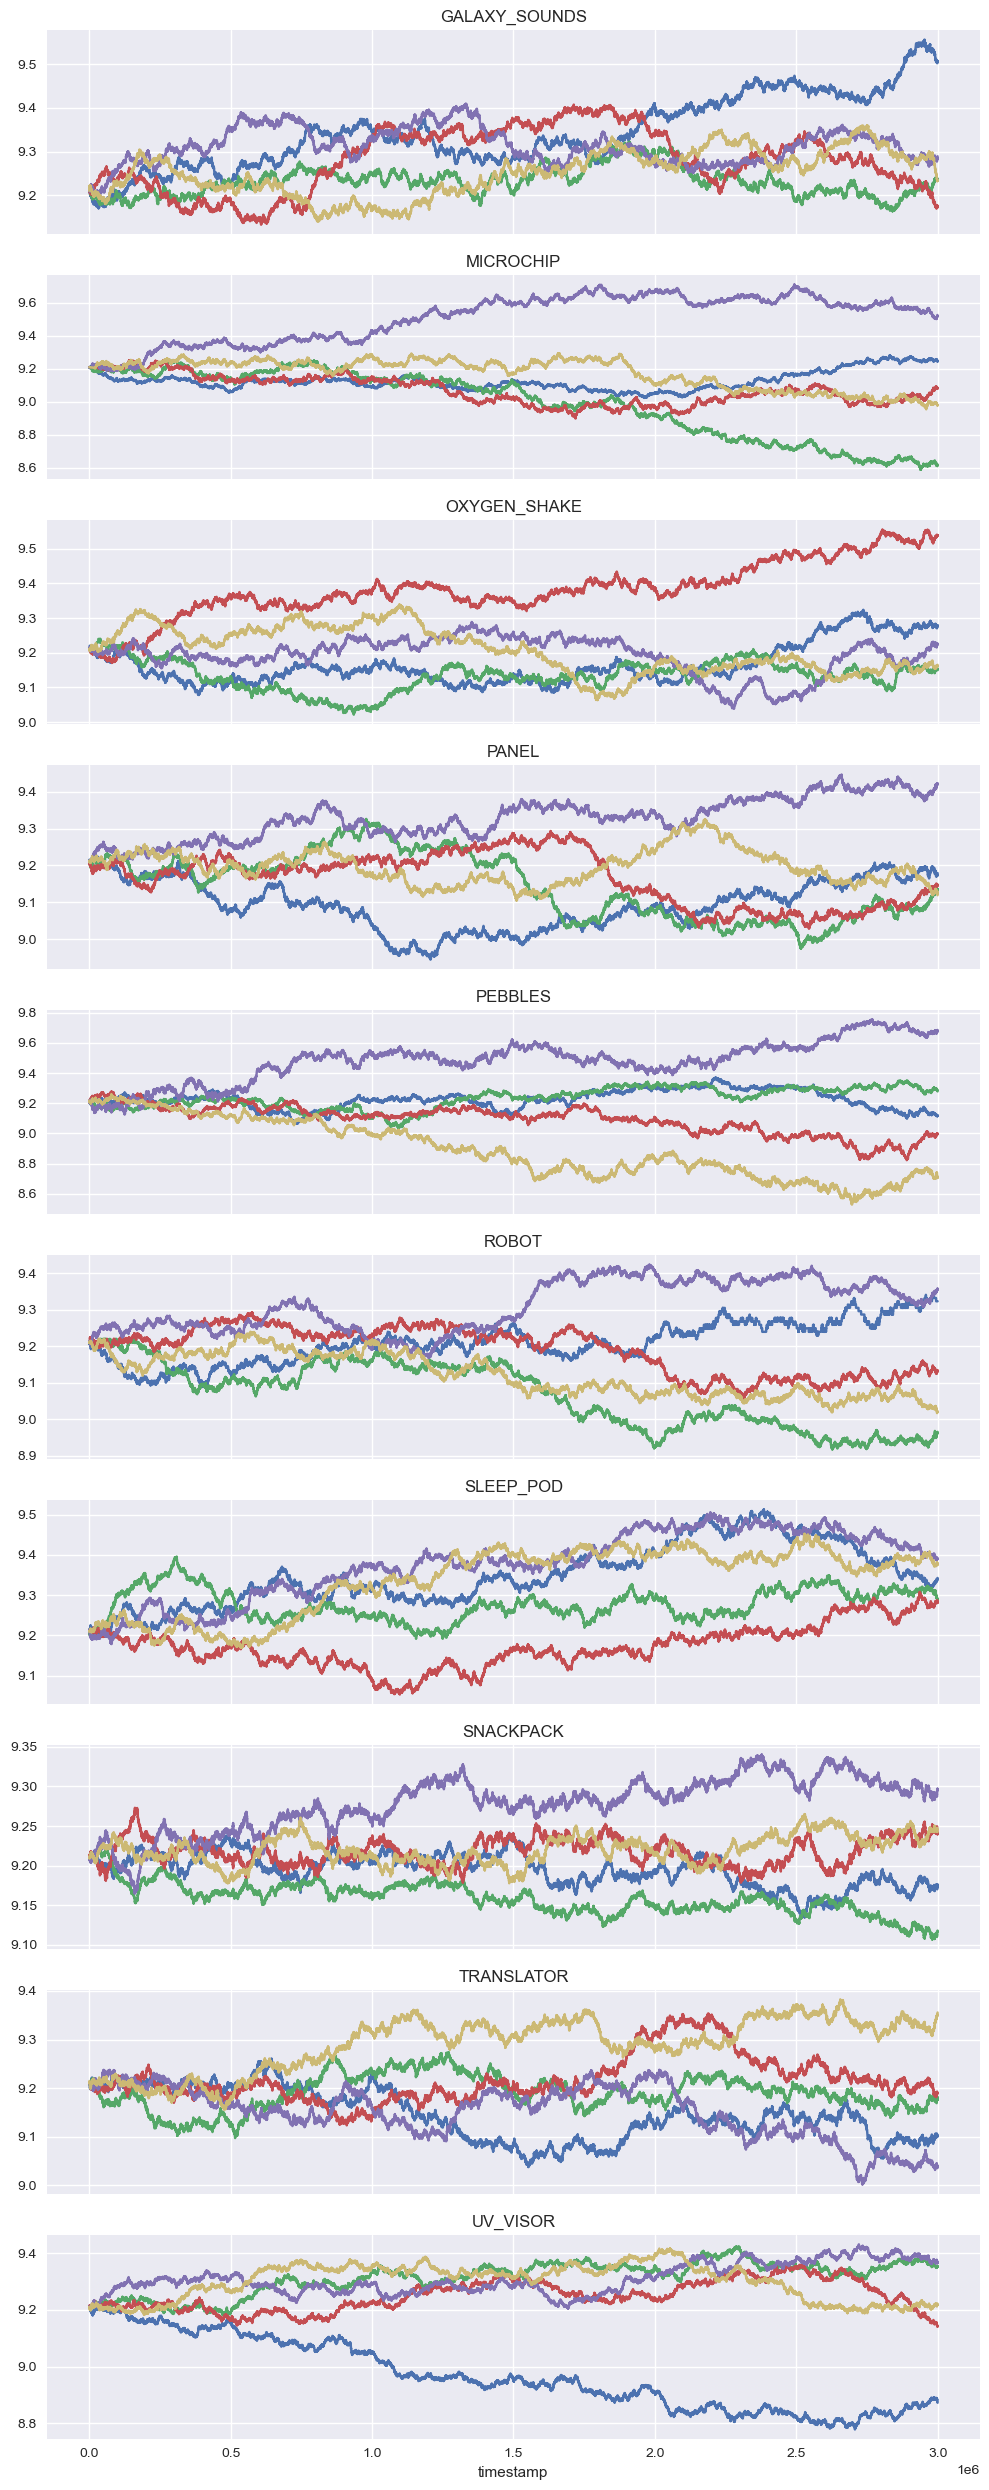

In [10]:
sectors = {
    "GALAXY_SOUNDS": np.log(gs),
    "MICROCHIP": np.log(mc),
    "OXYGEN_SHAKE": np.log(os),
    "PANEL": np.log(panel),
    "PEBBLES": np.log(pebble),
    "ROBOT": np.log(robot),
    "SLEEP_POD": np.log(sleep),
    "SNACKPACK": np.log(sp),
    "TRANSLATOR": np.log(trans),
    "UV_VISOR": np.log(uv)
}

fig, axes = plt.subplots(len(sectors), 1, figsize=(10, 25), sharex=True)

for ax, (name, df) in zip(axes, sectors.items()):
    df.plot(ax=ax, title=name, legend=False)

plt.tight_layout()
plt.show()